![alternative text](../logo.png)

# European Wind Storm Indicators – windstorm footprint example

This notebook shows how to retrieve **European windstorm data** using the `sis-european-wind-storm-indicators` dataset, using windstorm footprints as an example.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray DataArray**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What are European wind storm indicators?

This dataset provides climatological indicators on European winter windstorms and their economic impact derived from ERA5 reanalysis. A **windstorm footprint** is the maximum 3-second 10 m wind gust recorded at each grid point during the 72 hours after a storm is first identified — the single field that insurers and civil-protection agencies use to summarise how hard a storm hit and where. Footprints are statistically downscaled from the 31 km ERA5 reanalysis to a **1 km grid**, and the dataset covers 142 named winter storms between 1979 and 2021. Alongside footprints, it also offers storm tracks and loss, risk and summary indicators.

More information about **available variables** and **request fields** can be found in:
- README and constraints/sis-european-wind-storm-indicators.json
- https://cds.climate.copernicus.eu/datasets/sis-european-wind-storm-indicators?tab=overview

## Imports and shared settings

In [1]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [1]:
#Data requests and decode
import requests
import numpy as np
import xarray as xr

#Data visualisation
import earthkit.plots as ekp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

url = base_url.format(dataset='sis-european-wind-storm-indicators')

---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by two corner coordinates.

In this request, we retrieve the footprint of **storm Daria on 25 January 1990**, the dataset's default date. Daria — the *Burns' Day storm* — crossed the British Isles and the Low Countries, killed around 100 people across north-west Europe and remains one of the costliest European windstorms on record.

The bounding box covers southern Britain, the Low Countries and north-west Germany (roughly 50°N–54°N, 2°W–8°E), the corridor Daria travelled along.

Note that `variable` is a plain string, `'all'`, rather than a list — this dataset is the exception. The date fields are optional: omitting them gives you Daria anyway, since 1990-01-25 is the default.

The API returns data in **CoverageJSON** format.

### 1.1 Send the request

In [2]:
daria_bbox = [[50.0, -2.0], [54.0, 8.0]]   # [lat_min, lon_min], [lat_max, lon_max]

bbox_request = {
    'request': {
        'variable': 'all',                     # a plain string for this dataset, not a list
        'product': ['windstorm_footprints'],
        'year': ['1990'],
        'month': ['01'],
        'day': ['25'],
    },
    'feature': {
        'type': 'boundingbox',
        # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
        'coordinates': daria_bbox,
    },
}

response_bbox = requests.post(url, headers=headers, json=bbox_request)

#Print the response status code
print('Status:', response_bbox.status_code)

Status: 200


### 1.2 Decode the response

A footprint is a regular 1 km grid, so the response carries the latitude and longitude vectors in `domain.axes` (as `y` and `x`) and the gust values in `ranges.FX`. We read them into an [xarray DataArray](https://docs.xarray.dev/en/stable/), which gives us a labelled overview of the field and makes future post-processing straightforward.

In [3]:
coverage = response_bbox.json()
axes = coverage['domain']['axes']          # 'y' is latitude, 'x' is longitude
gust = coverage['ranges']['FX']

daria = xr.DataArray(
    np.array(gust['values'], dtype=float).reshape(gust['shape']),
    dims=('latitude', 'longitude'),
    coords={'latitude': axes['y']['values'], 'longitude': axes['x']['values']},
    name='FX',
    attrs={'units': 'm s-1', 'long_name': 'maximum 10 m wind gust'},
)
daria

<xarray.DataArray 'FX' (latitude: 240, longitude: 600)> Size: 1MB
array([[-1.        , -1.        , -1.        , ..., 29.88637161,
        29.76578331, 29.61503792],
       [-1.        , -1.        , -1.        , ..., 30.2781868 ,
        30.21505737, 30.01508522],
       [-1.        , -1.        , -1.        , ..., 30.70941925,
        30.71826553, 30.58433151],
       ...,
       [34.59184647, 34.717659  , 34.61632538, ..., -1.        ,
        -1.        , -1.        ],
       [34.0789299 , 34.09178543, 34.05840302, ..., -1.        ,
        -1.        , -1.        ],
       [33.97880173, 33.89604187, 33.83255768, ..., -1.        ,
        -1.        , -1.        ]], shape=(240, 600))
Coordinates:
  * latitude   (latitude) float64 2kB 50.0 50.02 50.03 ... 53.95 53.97 53.98
  * longitude  (longitude) float64 5kB -1.992 -1.975 -1.958 ... 7.975 7.991
Attributes:
    units:      m s-1
    long_name:  maximum 10 m wind gust

The variable is `FX`, the maximum 10 m gust in m/s over the 72-hour window. Grid points with no data — sea, and large inland water bodies such as the IJsselmeer — come back as `-1`.

### 1.3 Visualise the data

We use **Earthkit Plots** package to visualise the data.
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io

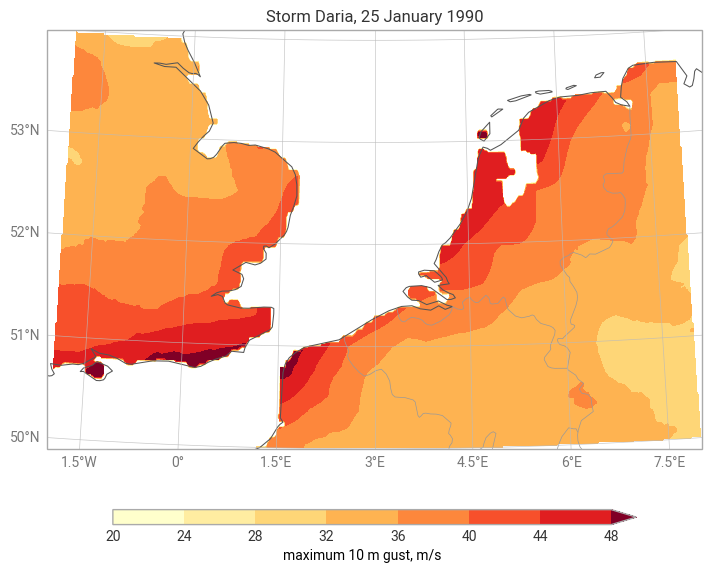

In [4]:
gust_levels = [20, 24, 28, 32, 36, 40, 44, 48]

chart = ekp.Map(domain=[-2.0, 8.0, 50.0, 54.0])
chart.contourf(daria,
    x=daria['longitude'],
    y=daria['latitude'],
    style=ekp.Style(levels=gust_levels, colors='YlOrRd', extend='max'))

chart.coastlines()
chart.borders()
chart.gridlines()
chart.title('Storm Daria, 25 January 1990')
chart.legend(label='maximum 10 m gust, m/s')

chart.show()

Well over half the land area in the box exceeded 32 m/s — hurricane force — and the strongest 5 %, above 44 m/s, is split between southern England and the Dutch coast, peaking at just under 50 m/s on the English south coast. The blank patch in the middle of the Netherlands is the IJsselmeer.

---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below traces **Germany**, and we switch to a later storm: **Kyrill, on 18 January 2007**. Kyrill is remembered less for a single extreme gust than for how widely it hit — Deutsche Bahn suspended long-distance services across the entire country, and 13 people died in Germany. Notice that **only the `feature` block and the date change** – the rest of the request is the same as in Example 1.

### 2.1 Send the request

In [5]:
# Closed polygon of [lat, lon] pairs - first point must equal last point
germany_polygon = [
    [54.90, 8.30],    # Danish border, North Frisian coast
    [54.50, 9.90],    # Flensburg
    [54.10, 11.00],
    [54.30, 13.10],   # Ruegen, Baltic coast
    [53.90, 14.25],   # Usedom, Polish border
    [52.85, 14.45],   # Oder
    [51.40, 15.05],   # Neisse
    [50.90, 14.80],   # Czech border at Zittau
    [50.70, 13.30],   # Ore Mountains
    [50.30, 12.10],
    [49.30, 12.60],   # Bavarian Forest
    [48.60, 13.80],   # Passau
    [47.70, 13.00],   # Austrian border near Salzburg
    [47.55, 10.20],   # Alps
    [47.60, 8.60],    # Lake Constance, Swiss border
    [47.90, 7.60],    # Upper Rhine
    [49.00, 8.20],    # Rhine, French border
    [49.50, 6.35],    # Saarland
    [50.15, 6.15],    # Eifel, Belgian border
    [50.80, 6.00],    # Aachen
    [51.85, 6.10],    # Dutch border
    [52.60, 7.05],    # Emsland
    [53.35, 7.20],    # Dollart
    [53.90, 8.10],    # Elbe mouth at Cuxhaven
    [54.90, 8.30],    # close polygon
]

polygon_request = {
    'request': {
        'variable': 'all',
        'product': ['windstorm_footprints'],
        'year': ['2007'],
        'month': ['01'],
        'day': ['18'],
    },
    'feature': {
        'type': 'polygon',
        'coordinates': germany_polygon,
    },
}

response_poly = requests.post(url, headers=headers, json=polygon_request)

# Print the response status code
print('Status:', response_poly.status_code)

Status: 200


### 2.2 Decode the response

As in the previous example, we read the grid out of the response.

In [6]:
coverage = response_poly.json()
axes = coverage['domain']['axes']          # 'y' is latitude, 'x' is longitude
gust = coverage['ranges']['FX']

kyrill = xr.DataArray(
    np.array(gust['values'], dtype=float).reshape(gust['shape']),
    dims=('latitude', 'longitude'),
    coords={'latitude': axes['y']['values'], 'longitude': axes['x']['values']},
    name='FX',
    attrs={'units': 'm s-1', 'long_name': 'maximum 10 m wind gust'},
)
kyrill

<xarray.DataArray 'FX' (latitude: 441, longitude: 543)> Size: 2MB
array([[-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]], shape=(441, 543))
Coordinates:
  * latitude   (latitude) float64 4kB 47.55 47.57 47.58 ... 54.85 54.87 54.88
  * longitude  (longitude) float64 4kB 6.008 6.025 6.041 ... 15.01 15.02 15.04
Attributes:
    units:      m s-1
    long_name:  maximum 10 m wind gust

### 2.3 Visualise the data

We reuse `gust_levels` from Example 1, so the two storms can be compared directly.

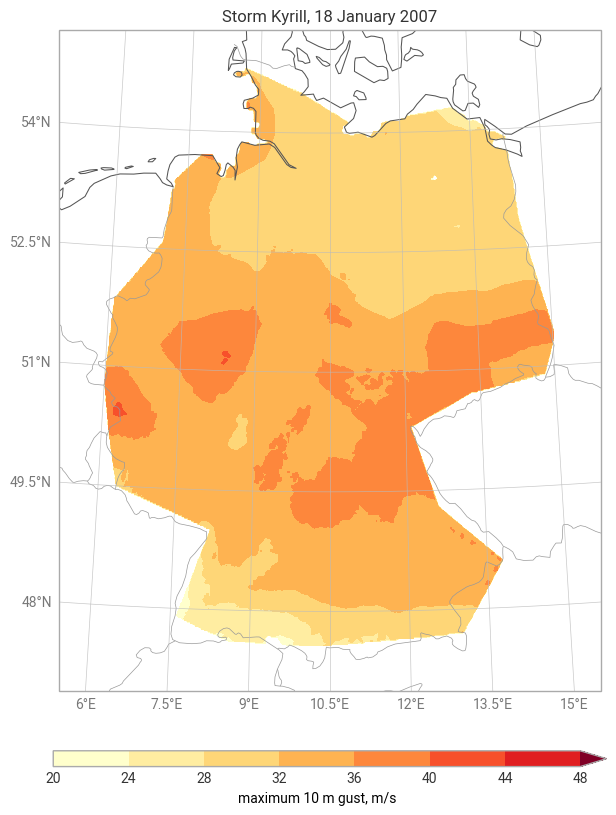

In [7]:
chart = ekp.Map(domain=[5.5, 15.5, 47.0, 55.2])
chart.contourf(kyrill,
    x=kyrill['longitude'],
    y=kyrill['latitude'],
    style=ekp.Style(levels=gust_levels, colors='YlOrRd', extend='max'))

chart.coastlines()
chart.borders()
chart.gridlines()
chart.title('Storm Kyrill, 18 January 2007')
chart.legend(label='maximum 10 m gust, m/s')

chart.show()

Kyrill covers the country almost uniformly in the 32–40 m/s band, with its strongest core over the uplands of North Rhine-Westphalia and Hesse. Its peak gust, 40.6 m/s, is lower than the 49.9 m/s Daria reached in Example 1, but the hurricane-force contour covers roughly two thirds of Germany — which is what made it so disruptive.

---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Pick another storm** – the constraints file lists all 142 available dates, among them Lothar (1999-12-26), Klaus (2009-01-24) and the Great Storm of 1987 (1987-10-16). Note that footprints cover a 72-hour window, so storms a day apart return nearly the same field
- **Change the product** – `windstorm_tracks` gives the storm centre path, and `loss_indicators`, `risk_indicators` and `summary_indicators` give damage-related aggregates
- **Aggregate by country or sector** – `spatial_aggregation` accepts country names, NUTS1/NUTS3 regions, and sectors such as `residential`, `industry` and `agriculture`
- **Rank the storms** – loop over a set of dates for one polygon and sort them by the area above a gust threshold
- **Use a real boundary** – load a country shapefile and convert it to a polygon for the API

Please see the constraints file, which contains the valid values for the dataset.